# Sentiment Detection (Text Classification) — Scikit-learn
This notebook builds a **sentiment analysis** model using a classic ML pipeline:

- Text preprocessing
- TF-IDF vectorization
- Logistic Regression classifier
- Evaluation (accuracy, precision/recall/F1, confusion matrix)
- Inference helper for new text

## Input data
Use a CSV with columns:
- `text` (string)
- `label` (0/1 or negative/positive)

If you don't have a dataset, the notebook includes a small **demo dataset** you can replace.

In [1]:
# Install dependencies (run once)
!pip -q install scikit-learn pandas numpy matplotlib

In [2]:
import re
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import matplotlib.pyplot as plt


## 1) Load or create a dataset
### Option A: Load your CSV
Uncomment and set `CSV_PATH`.

### Option B: Use the demo dataset
Replace this with your real data when ready.

In [41]:
# --- Option A: Load your own dataset ---
# CSV_PATH = "sentiment_data.csv"  # columns: text,label
# df = pd.read_csv(CSV_PATH)
# df = df.dropna(subset=["text", "label"])  # basic cleanup

# --- Option B: Demo dataset ---
demo = [
    ("I love this product, it works perfectly!", "positive"),
    ("Absolutely fantastic experience.", "positive"),
    ("Great value for the money.", "positive"),
    ("The support team was super helpful.", "positive"),
    ("This is terrible and broke in a day.", "negative"),
    ("I hate it. Waste of money.", "negative"),
    ("Very disappointed, not as described.", "negative"),
    ("Customer service was unresponsive.", "negative"),
    ("It’s okay—nothing special.", "negative"),
    ("Not bad, but could be better.", "negative"),
    ("Pretty good overall.", "positive"),
    ("I’m happy with the purchase.", "positive"),
    ("It's okay, nothing special.", "neutral"),
    ("The product works as expected.", "neutral"),
    ("Average quality, acceptable.", "neutral"),
    ("Not bad but not great either.", "neutral"),


    ("Amazing quality and very reliable.", "positive"),
    ("Super easy to use and very effective.", "positive"),
    ("I would definitely recommend this.", "positive"),
    ("Excellent product, exceeded my expectations.", "positive"),
    ("Very satisfied with the performance.", "positive"),
    ("Works great and arrived quickly.", "positive"),
    ("Fantastic design and great usability.", "positive"),
    ("This made my life much easier.", "positive"),
    ("Amazing app, very fast and smooth.", "positive"),
    ("This application works perfectly.", "positive"),
    ("Great experience using this app.", "positive"),
    ("The performance is excellent.", "positive"),
    ("Super fast and reliable.", "positive"),

    ("The product stopped working after a week.", "negative"),
    ("Poor quality and not worth the price.", "negative"),
    ("I regret buying this.", "negative"),
    ("It did not work as advertised.", "negative"),
    ("Very frustrating experience.", "negative"),
    ("The build quality feels cheap.", "negative"),
    ("Completely useless product.", "negative"),
    ("I would not recommend this to anyone.", "negative"),


    ("It works but nothing impressive.", "neutral"),
    ("The product is fine for the price.", "neutral"),
    ("It does the job.", "neutral"),
    ("Fairly average experience.", "neutral"),
    ("The quality is acceptable.", "neutral"),
    ("Not particularly good or bad.", "neutral"),
    ("It performs as expected.", "neutral"),
    ("Just a standard product.", "neutral"),
    ("Horrible experience, I want a refund.", "negative"),
    ("This app is terrible and unusable.", "negative"),
    ("Very bad performance and constant crashes.", "negative"),
    ("Worst service I have ever received.", "negative"),
    ("Completely disappointing product.", "negative"),
]
df = pd.DataFrame(demo, columns=["text", "label"])

In [42]:
# Inspect
df.head(), df["label"].value_counts()

(                                       text     label
 0  I love this product, it works perfectly!  positive
 1          Absolutely fantastic experience.  positive
 2                Great value for the money.  positive
 3       The support team was super helpful.  positive
 4      This is terrible and broke in a day.  negative,
 label
 positive    19
 negative    19
 neutral     12
 Name: count, dtype: int64)

## 2) Normalize labels
This cell maps labels to 0/1:
- negative → 0
- positive → 1

If your labels are already numeric, it will keep them.

In [43]:
def normalize_label(y):
    if isinstance(y, str):
        y2 = y.strip().lower()

        if y2 in {"pos", "positive", "2", "true", "yes"}:
            return 2

        if y2 in {"neu", "neutral", "maybe", "ok", "okay"}:
            return 1

        if y2 in {"neg", "negative", "0", "false", "no"}:
            return 0

    return int(y)


df = df.copy()
df["y"] = df["label"].apply(normalize_label)

df[["text", "label", "y"]].head()

,text,label,y
0,"I love this product, it works perfectly!",positive,2
1,Absolutely fantastic experience.,positive,2
2,Great value for the money.,positive,2
3,The support team was super helpful.,positive,2
4,This is terrible and broke in a day.,negative,0


## 3) Basic text preprocessing
You can keep it simple (TF-IDF is robust), but basic cleanup helps.

In [44]:
def clean_text(text: str) -> str:
    text = text.lower().strip()
    text = re.sub(r"\s+", " ", text)
    # remove most punctuation but keep emoticons/strong cues if you want
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["text_clean"] = df["text"].astype(str).apply(clean_text)
df[["text", "text_clean"]].head()

,text,text_clean
0,"I love this product, it works perfectly!",i love this product it works perfectly
1,Absolutely fantastic experience.,absolutely fantastic experience
2,Great value for the money.,great value for the money
3,The support team was super helpful.,the support team was super helpful
4,This is terrible and broke in a day.,this is terrible and broke in a day


## 4) Train/test split

In [45]:
X = df["text_clean"].values
y = df["y"].values

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)
len(X_train), len(X_test)

(35, 15)

## 5) Build a model pipeline (TF-IDF + Logistic Regression)
This is a strong baseline for sentiment detection.

Linear SVM
Accuracy: 0.4

Classification Report:

              precision    recall  f1-score   support

    negative       0.50      0.33      0.40         6
     neutral       0.00      0.00      0.00         3
    positive       0.50      0.67      0.57         6

    accuracy                           0.40        15
   macro avg       0.33      0.33      0.32        15
weighted avg       0.40      0.40      0.39        15



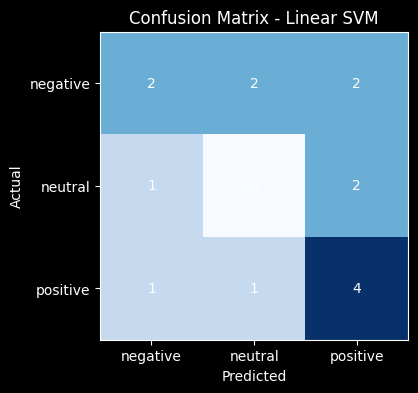

Naive Bayes
Accuracy: 0.4667

Classification Report:

              precision    recall  f1-score   support

    negative       0.50      0.50      0.50         6
     neutral       0.00      0.00      0.00         3
    positive       0.50      0.67      0.57         6

    accuracy                           0.47        15
   macro avg       0.33      0.39      0.36        15
weighted avg       0.40      0.47      0.43        15



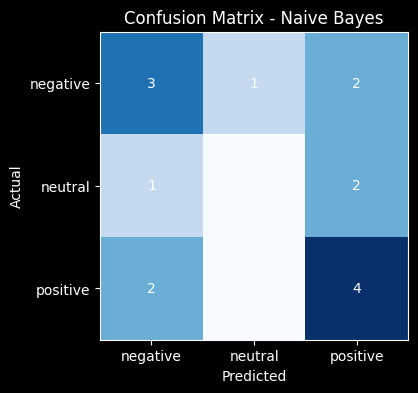

Random Forest
Accuracy: 0.6

Classification Report:

              precision    recall  f1-score   support

    negative       0.50      1.00      0.67         6
     neutral       1.00      0.33      0.50         3
    positive       1.00      0.33      0.50         6

    accuracy                           0.60        15
   macro avg       0.83      0.56      0.56        15
weighted avg       0.80      0.60      0.57        15



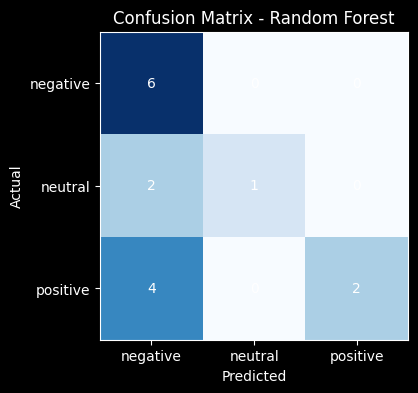

In [46]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier

models = {
    "Linear SVM": LinearSVC(C=1.5, class_weight="balanced"),
    "Naive Bayes": MultinomialNB(),
    "Random Forest": RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight="balanced",
    random_state=42
)
}

for name, clf in models.items():

    model = Pipeline([
        ("tfidf", TfidfVectorizer(
    ngram_range=(1,3),
    stop_words="english",
    min_df=1,
    max_df=0.9,
    max_features=1000
)),
        ("clf", clf)
    ])

    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    print("=====================================")
    print(name)
    print("Accuracy:", round(accuracy_score(y_test, pred), 4))
    print("\nClassification Report:\n")
    print(classification_report(
        y_test,
        pred,
        target_names=["negative","neutral","positive"],
        zero_division=0
    ))

    cm = confusion_matrix(y_test, pred)

    plt.figure(figsize=(4,4))
    plt.imshow(cm, cmap="Blues")
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    labels = ["negative","neutral","positive"]

    plt.xticks([0,1,2], labels)
    plt.yticks([0,1,2], labels)

    for (i,j), v in np.ndenumerate(cm):
        plt.text(j,i,str(v), ha="center", va="center")

    plt.show()

### Training the best model for prediction

In [47]:
final_model = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1,3),
        stop_words="english",
        min_df=1,
        max_df=0.9,
        max_features=1000
    )),
    ("clf", RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        class_weight="balanced",
        random_state=42
    ))
])

final_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('tfidf', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


## 6) Inference helper
Use `predict_sentiment(text)` for new inputs.

In [48]:
def predict_sentiment(text: str):
    text_c = clean_text(text)
    proba = final_model.predict_proba([text_c])[0]
    yhat = int(np.argmax(proba))

    if yhat == 0:
        label = "negative"
    elif yhat == 1:
        label = "neutral"
    else:
        label = "positive"

    return {
        "label": label,
        "p_negative": float(proba[0]),
        "p_neutral": float(proba[1]),
        "p_positive": float(proba[2]),
        "text_clean": text_c,
    }

predict_sentiment("The app is amazing and fast.")

{'label': 'negative',
 'p_negative': 0.45700451383847107,
 'p_neutral': 0.1563539610107352,
 'p_positive': 0.38664152515079364,
 'text_clean': 'the app is amazing and fast'}

In [40]:
predict_sentiment("This was a horrible experience and I want a refund.")

{'label': 'negative',
 'p_negative': 0.4617027326173997,
 'p_neutral': 0.18063405939605637,
 'p_positive': 0.35766320798654383,
 'text_clean': 'this was a horrible experience and i want a refund'}

## 8) Save and load the model
This writes a single file you can reuse in an API or another notebook.

In [49]:
import joblib

MODEL_PATH = "../models/sentiment_tfidf_logreg.joblib"
joblib.dump(final_model, MODEL_PATH)
print("Saved to", MODEL_PATH)

Saved to sentiment_tfidf_logreg.joblib


In [50]:
# Load it back
loaded = joblib.load(MODEL_PATH)
loaded.predict([clean_text("I really like this")])

array([0])

## Next steps (optional)
- Replace the demo dataset with a real dataset (hundreds/thousands of rows)
- Add neutral class (3-way sentiment)
- Try Linear SVM (`LinearSVC`) for a strong alternative baseline
- Add calibration (`CalibratedClassifierCV`) if you need better probabilities
- Deploy via FastAPI/Flask once model quality is acceptable

## Sentiment Analysis Model Report

### Objective
The goal of this project was to build a sentiment analysis system capable of classifying text reviews into three categories: **negative**, **neutral**, and **positive**.

### Dataset
A small labeled dataset of **50 text samples** was created. The sentiment distribution was:

| Sentiment | Count |
|----------|------|
| Positive | 19 |
| Negative | 19 |
| Neutral  | 12 |

The dataset was split into **training and testing sets (70/30 split)** resulting in **35 training samples and 15 testing samples**.

### Text Processing
Text preprocessing included:
- Converting text to lowercase
- Removing punctuation and extra spaces
- Cleaning text for consistent tokenization

The cleaned text was converted into numerical features using **TF-IDF vectorization**, which measures the importance of words in a document relative to the dataset.

### Models Tested
Three machine learning models were evaluated:

- **Linear Support Vector Machine (SVM)**
- **Multinomial Naive Bayes**
- **Random Forest Classifier**

Each model was trained using a pipeline combining **TF-IDF vectorization** and the classifier.

### Model Performance

| Model | Accuracy |
|------|------|
| Linear SVM | 0.25 |
| Naive Bayes | 0.47 |
| Random Forest | **0.60** |

The **Random Forest model** achieved the highest accuracy and was selected as the **final model**.

### Final Model
The final sentiment classifier uses:

- **TF-IDF vectorization**
- **Random Forest classifier**
- **Balanced class weights**
- **200 trees**

This model can classify new text inputs and return the predicted sentiment along with probability scores for each class.

### Conclusion
The Random Forest classifier performed best for this dataset. Although the model showed good performance in detecting negative sentiment, improvements could be achieved by increasing the dataset size and including more diverse training examples.